In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.ndimage import maximum_filter
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import maximum_filter
import folium
from folium.plugins import MarkerCluster

In [3]:
trees = gpd.read_file("../../data/processed/philly_trees.geojson").to_crs(epsg=2272)

In [4]:
def find_hotspots(gdf, scientific_name, grid_size=300, bandwidth=None,
                  peak_threshold=0.3, min_separation=10, min_trees=20):
    """
    KDE-based hotspot detection for one species.

    bandwidth      : None = Scott's rule. Try a float (in CRS units, here feet)
                     to force a tighter/looser kernel.
    peak_threshold : keep peaks >= this fraction of the max density.
    min_separation : min grid cells between peaks (controls how clustered hotspots can be).
    """
    sp = gdf[gdf['scientific_name'] == scientific_name]
    if len(sp) < min_trees:
        return pd.DataFrame()

    x, y = sp.geometry.x.values, sp.geometry.y.values

    # Grid covering species extent (with small padding)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    px, py = (xmax - xmin) * 0.02, (ymax - ymin) * 0.02
    xx, yy = np.mgrid[xmin-px:xmax+px:complex(grid_size),
                      ymin-py:ymax+py:complex(grid_size)]
    grid = np.vstack([xx.ravel(), yy.ravel()])

    # KDE
    kde = gaussian_kde(np.vstack([x, y]), bw_method=bandwidth)
    dens = kde(grid).reshape(xx.shape)

    # Local maxima above threshold
    peaks = (dens == maximum_filter(dens, size=min_separation)) \
            & (dens >= peak_threshold * dens.max())
    idx = np.argwhere(peaks)

    out = pd.DataFrame({
        'scientific_name': scientific_name,
        'tree_count': len(sp),
        'x': xx[idx[:, 0], idx[:, 1]],
        'y': yy[idx[:, 0], idx[:, 1]],
        'density': dens[idx[:, 0], idx[:, 1]],
    }).sort_values('density', ascending=False).reset_index(drop=True)
    out['rank'] = out.index + 1
    return out



# one species
hot = find_hotspots(trees, 'Ginkgo biloba')

# all reasonably common species
counts = trees['scientific_name'].value_counts()
common = counts[counts >= 100].index
all_hot = pd.concat([find_hotspots(trees, sp) for sp in common], ignore_index=True)

# back to a GeoDataFrame so you can map / export
hot_gdf = gpd.GeoDataFrame(
    all_hot,
    geometry=gpd.points_from_xy(all_hot.x, all_hot.y),
    crs=trees.crs,
)

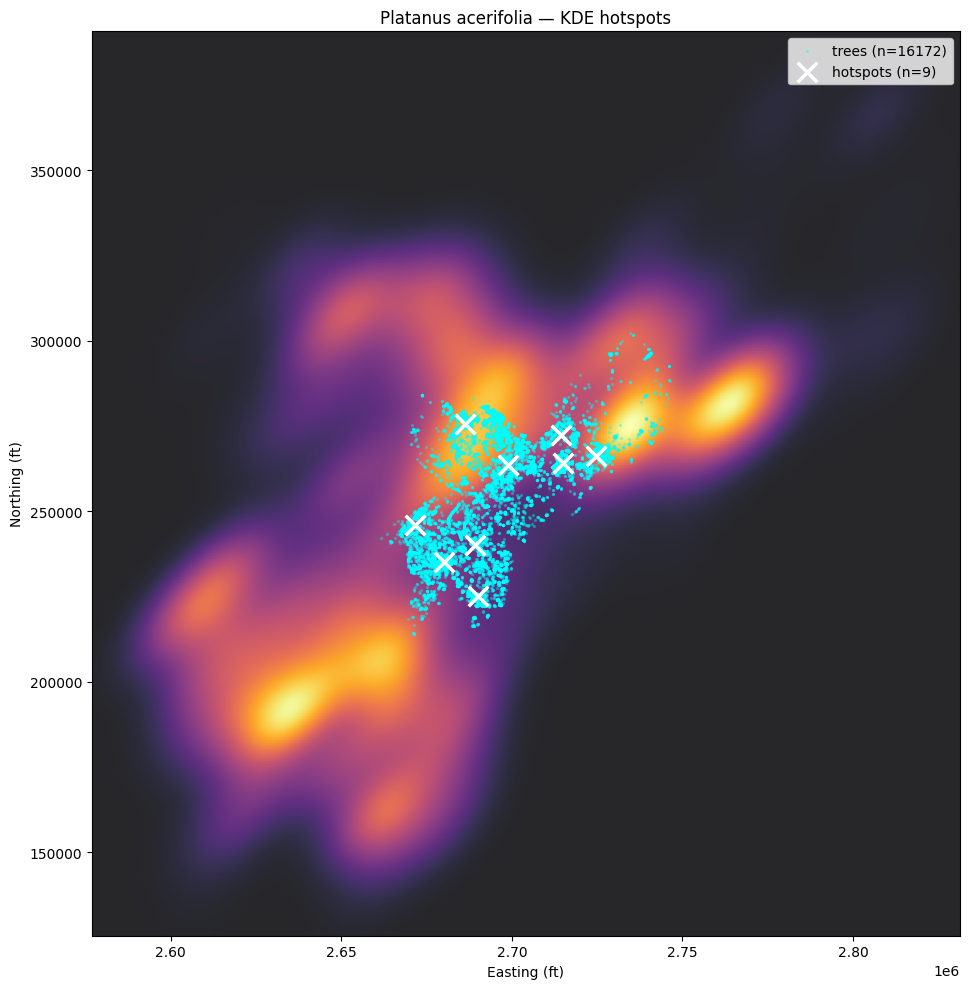

In [5]:
def plot_species_kde(gdf, scientific_name, grid_size=300, bandwidth=None,
                     peak_threshold=0.3, min_separation=10):
    """Heatmap + tree points + detected peaks for one species."""
    sp = gdf[gdf['scientific_name'] == scientific_name]
    x, y = sp.geometry.x.values, sp.geometry.y.values

    xmin, xmax, ymin, ymax = x.min(), x.max(), y.min(), y.max()
    px, py = (xmax - xmin) * 0.02, (ymax - ymin) * 0.02
    xx, yy = np.mgrid[xmin-px:xmax+px:complex(grid_size),
                      ymin-py:ymax+py:complex(grid_size)]
    kde = gaussian_kde(np.vstack([x, y]), bw_method=bandwidth)
    dens = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    peaks = (dens == maximum_filter(dens, size=min_separation)) \
            & (dens >= peak_threshold * dens.max())
    pidx = np.argwhere(peaks)
    px_, py_ = xx[pidx[:, 0], pidx[:, 1]], yy[pidx[:, 0], pidx[:, 1]]

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(dens.T, origin='lower', cmap='inferno',
              extent=[xmin-px*50, xmax+px*50, ymin-py*50, ymax+py*50],
              aspect='equal', alpha=0.85)
    ax.scatter(x, y, s=2, c='cyan', alpha=0.3, label=f'trees (n={len(sp)})')
    ax.scatter(px_, py_, s=200, marker='x', c='white', linewidths=2.5,
               label=f'hotspots (n={len(px_)})')
    ax.set_title(f'{scientific_name} — KDE hotspots')
    ax.legend(loc='upper right')
    ax.set_xlabel('Easting (ft)'); ax.set_ylabel('Northing (ft)')
    plt.tight_layout()
    plt.show()

plot_species_kde(trees, 'Platanus acerifolia')

In [12]:
import folium
from folium.plugins import MarkerCluster

def map_hotspots(gdf, hotspots_df, scientific_name, sample_trees=2000):
    """Interactive map: tree points (sampled) + hotspot markers on OSM basemap."""
    sp = gdf[gdf['scientific_name'] == scientific_name].to_crs(4326)
    if len(sp) > sample_trees:
        sp = sp.sample(sample_trees, random_state=0)

    hot = hotspots_df[hotspots_df['scientific_name'] == scientific_name].copy()
    # convert hotspot x/y from State Plane → lat/lon
    hot_gdf = gpd.GeoDataFrame(
        hot, geometry=gpd.points_from_xy(hot.x, hot.y), crs=gdf.crs
    ).to_crs(4326)

    center = [sp.geometry.y.mean(), sp.geometry.x.mean()]
    m = folium.Map(location=center, zoom_start=13)

    # tree points (clustered so it stays responsive)
    cluster = MarkerCluster(name='trees').add_to(m)
    for pt in sp.geometry:
        folium.CircleMarker([pt.y, pt.x], radius=2, color='green',
                            fill=True, fill_opacity=0.6).add_to(cluster)

    # hotspot markers, sized by rank
    for _, r in hot_gdf.iterrows():
        folium.CircleMarker(
            [r.geometry.y, r.geometry.x],
            radius=14 - min(r['rank'], 10),
            color='red', weight=3, fill=True, fill_color='red', fill_opacity=0.4,
            popup=f"#{r['rank']} • density={r['density']:.2e}",
        ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

m = map_hotspots(trees, all_hot, 'Prunus species')
m  # or display inline in Jupyter

In [9]:
all_hot


,scientific_name,tree_count,x,y,density,rank
0,Platanus acerifolia,16172,2.714850e+06,264118.095314,9.122763e-10,1
1,Platanus acerifolia,16172,2.724580e+06,266269.059101,8.929190e-10,2
2,Platanus acerifolia,16172,2.680058e+06,235233.724455,8.863902e-10,3
3,Platanus acerifolia,16172,2.689198e+06,240150.213112,7.852732e-10,4
4,Platanus acerifolia,16172,2.698928e+06,263503.534232,7.805280e-10,5
...,...,...,...,...,...,...
351,Quercus robur,105,2.688049e+06,276457.106536,5.890035e-10,2
352,Quercus robur,105,2.673603e+06,222910.631137,2.893288e-10,3
353,Fagus sylvatica,104,2.682167e+06,248815.190688,8.535070e-10,1
354,Fagus sylvatica,104,2.688839e+06,218294.717304,2.826566e-10,2
